In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### Erosion function

In [20]:
def erosion(image, structuring_element):
    eroded_image = image.copy()
    structuring_element = structuring_element*255
    offset = structuring_element.shape[0]//2
    height, width = image.shape
    for i in range(height):
        for j in range(width):
            fit = True
            for x in range(-offset, offset):
                for y in range(-offset, offset):
                    if (i+x>=0 and i+x<height and j+y>=0 and j+y<width):
                        if structuring_element[x+offset][y+offset]>0 and structuring_element[x+offset][y+offset] != image[i+x][j+y]:
                            fit = False
                    elif structuring_element[x+offset][y+offset]>0:
                        fit = False
            if fit:
                eroded_image[i][j] = 255
            else:
                eroded_image[i][j] = 0
    return eroded_image

### Applying boundry extraction

In [21]:
def boundry_extraction(image, structuring_element):
    return image.copy() - erosion(image, structuring_element)

### Creating structuring element

In [22]:
size = 5
structuring_element = np.ones((size, size))

### Loading original image

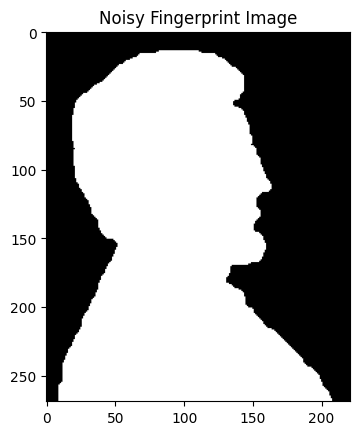

In [23]:
original_image = cv2.imread("Lincoln 221x269.tif", 0)
plt.imshow(original_image, cmap = "gray")
plt.title("Noisy Fingerprint Image")
plt.show()

### Applying Boundry Extraction

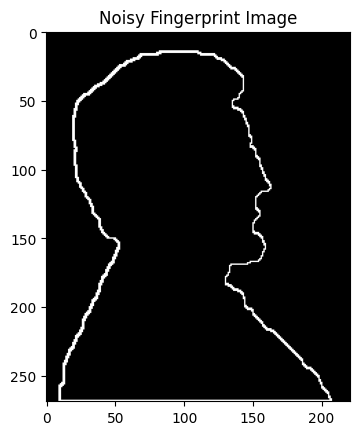

In [24]:
boundry_extracted_image = boundry_extraction(original_image, structuring_element)
plt.imshow(boundry_extracted_image, cmap = "gray")
plt.title("Noisy Fingerprint Image")
plt.show()